<a href="https://colab.research.google.com/github/agatastachowiak/eeg-motor-imagery-bci/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import mne

# MNE has a built-in downloader for this exact dataset.
# I'm grabbing data from just subject 1, run 6 (one of the motor imagery runs), to start.
from mne.datasets import eegbci

subject = 1
runs = [6]  # run 6 = one of the imagined movement runs in this dataset

raw_fnames = eegbci.load_data(subject, runs)
print(raw_fnames)

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m40s (2.5 MB)
[PosixPath('/root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf')]


In [ ]:
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)
print(raw)
print(raw.info)

Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


-	64 channels (electrodes) x 20000 (time points)
-	the recording is 125 seconds long
-	Sampling rate: 160 measurements per second per channel.
-	125 seconds × 160 Hz = 20,000 time points

Using matplotlib as 2D backend.


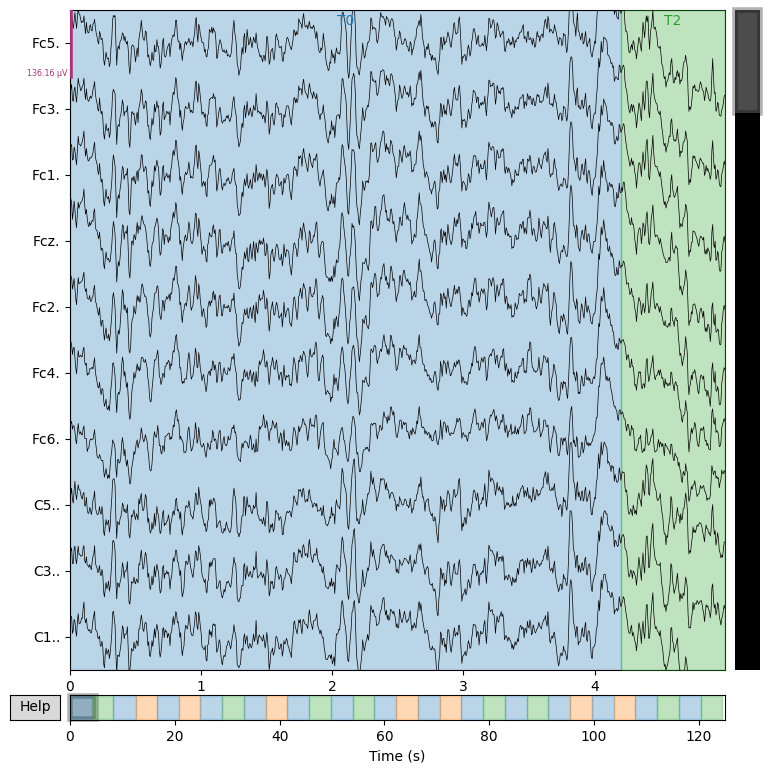

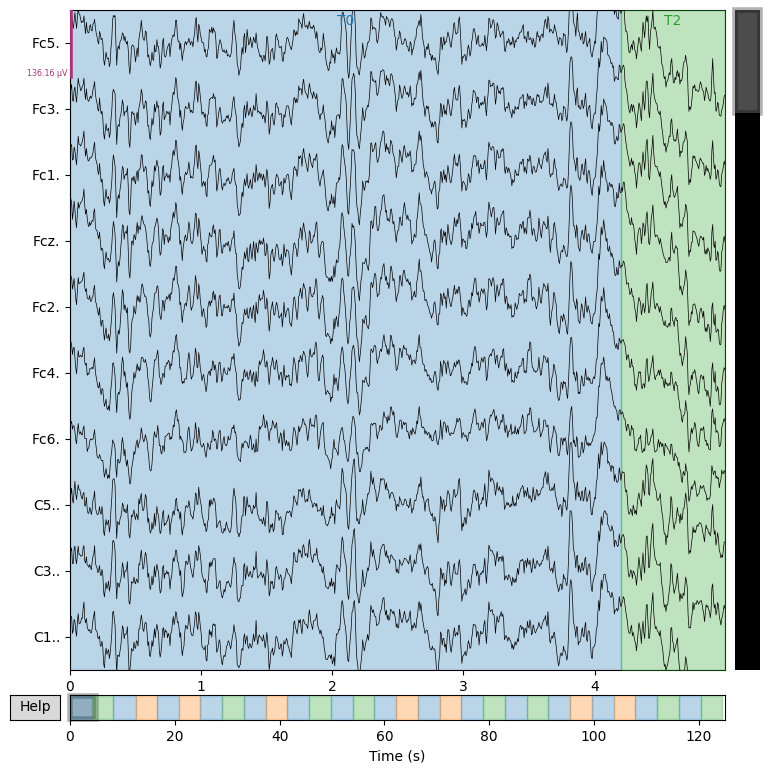

In [ ]:
raw.plot(n_channels=10, duration=5, scalings='auto')

In [ ]:
events, event_id = mne.events_from_annotations(raw)

print("Event ID mapping:", event_id)
print("Number of events:", len(events))
print(events[:10])  # show the first 10 events

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event ID mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Number of events: 30
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]


Mu rhythm — brain activity around 8–12 Hz, specifically over motor areas, that decreases when someone moves or imagines moving. This is one of the classic signals BCI systems rely on.

Beta rhythm — 13–30 Hz, also motor-related, often increases right after a movement.


In [ ]:
raw_filtered = raw.copy().filter(l_freq=8, h_freq=30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



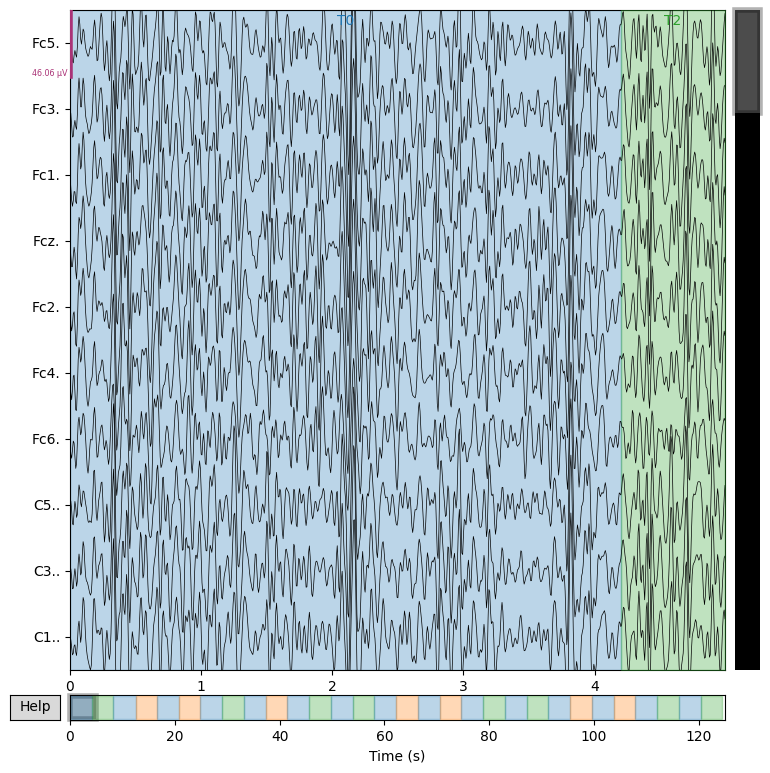

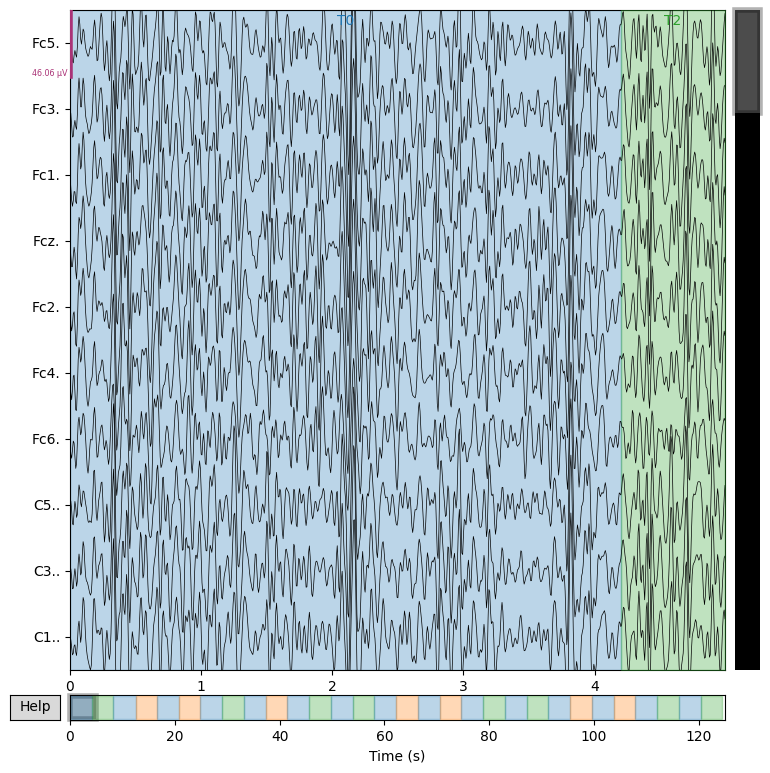

In [ ]:
raw_filtered.plot(n_channels=10, duration=5, scalings='auto')

In [ ]:
epochs = mne.Epochs(raw_filtered, events, event_id=event_id,
                     tmin=-0.5, tmax=2.0, baseline=None, preload=True)

print(epochs)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 401 original time points ...
1 bad epochs dropped
<Epochs | 29 events (all good), -0.5 – 2 s (baseline off), ~5.7 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>


T0: 14 — 14 rest epochs

T1: 7 — 7 left-fist epochs

T2: 8 — 8 right-fist epochs


In [ ]:
import numpy as np

# PSD for mu band (8-12 Hz) and beta band (13-30 Hz), separately per channel
psd_mu = epochs.compute_psd(fmin=8, fmax=12).get_data()   # shape: (epochs, channels, freqs)
psd_beta = epochs.compute_psd(fmin=13, fmax=30).get_data()

# Average across frequency bins within each band -> one value per channel per epoch
mu_power = psd_mu.mean(axis=2)      # shape: (epochs, channels)
beta_power = psd_beta.mean(axis=2)  # shape: (epochs, channels)

# Combine into one feature matrix: each epoch = [mu power per channel, beta power per channel]
X = np.concatenate([mu_power, beta_power], axis=1)
print("Feature matrix shape:", X.shape)

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Feature matrix shape: (29, 128)


29 epochs, 128 features (64 channels × 2 bands)

In [ ]:
y = epochs.events[:, -1]
print("Labels:", y)
print("Label meaning:", event_id)

Labels: [3 1 2 1 2 1 3 1 2 1 3 1 3 1 2 1 2 1 3 1 3 1 2 1 2 1 3 1 3]
Label meaning: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


Pattern: label 1 (T0/rest) appears constantly alternating with 2 or 3 (movement). This matches the experimental structure: rest → movement → rest → movement...

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf = SVC(kernel='linear')
scores = cross_val_score(clf, X, y, cv=3)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.5        0.4        0.55555556]
Mean accuracy: 0.4851851851851852
